# KIARA — DINOv2 Fine-Tuning for Diabetic Retinopathy Classification
### Knowledge-based Intelligent Analysis for Retinal Assessment

**Backbone:** Meta DINOv2 (ViT-Base/14, self-supervised pretraining), via `timm`
**Framework:** PyTorch
**Dataset:** APTOS 2019 Blindness Detection (5-class severity grading)

This notebook fine-tunes a DINOv2 Vision Transformer as a fourth model in
the KIARA comparison suite, alongside ResNet50, ViT, and Swin Transformer.
To keep the comparison fair, this notebook uses the **exact same
224x224 resolution and the exact same train/validation/test splits** as
the other three models, and applies **no test-time augmentation**, so
its reported metrics are directly comparable.

| Class | Meaning |
|---|---|
| 0 | No DR |
| 1 | Mild |
| 2 | Moderate |
| 3 | Severe |
| 4 | Proliferative DR |

**A note on resolution.** DINOv2 was natively pretrained at 518x518 with
14x14 patches (37x37 = 1,369 patches). Forcing 224x224 input (16x16 =
256 patches) for cross-model comparability means `timm` must interpolate
the pretrained positional embeddings to a smaller grid at load time.
This is standard, well-supported practice in `timm`, but it does mean
DINOv2 is not running at its best-known resolution here -- that trade-off
is deliberate, in service of a fair, apples-to-apples comparison with
the other three architectures.


In [1]:
# ------------------------------------------------------------------
# Install/upgrade timm to a version with DINOv2 hub weights available.
# ------------------------------------------------------------------
!pip install -q "timm>=0.9.16" torchmetrics scikit-learn tqdm


In [2]:

# ------------------------------------------------------------------
# Standard library
# ------------------------------------------------------------------
import os
import time
import random
import warnings

# ------------------------------------------------------------------
# Numerical / data handling
# ------------------------------------------------------------------
import numpy as np
import pandas as pd

# ------------------------------------------------------------------
# Image handling
# ------------------------------------------------------------------
from PIL import Image

# ------------------------------------------------------------------
# Visualization
# ------------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------------
# PyTorch core
# ------------------------------------------------------------------
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torch.cuda.amp import autocast, GradScaler

# ------------------------------------------------------------------
# Model backbone
# ------------------------------------------------------------------
import timm

# ------------------------------------------------------------------
# Metrics
# ------------------------------------------------------------------
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.preprocessing import label_binarize

# ------------------------------------------------------------------
# Progress bars
# ------------------------------------------------------------------
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

print(f"PyTorch version : {torch.__version__}")
print(f"timm version    : {timm.__version__}")


PyTorch version : 2.10.0+cu128
timm version    : 1.0.26


In [8]:
# Configuration

class Config:
    """Central configuration for the KIARA DINOv2 fine-tuning notebook."""

    # ---------------- Dataset paths ----------------
    DATA_DIR = "/kaggle/input/datasets/mariaherrerot/aptos2019"

    TRAIN_CSV = os.path.join(DATA_DIR, "train_1.csv")
    VALID_CSV = os.path.join(DATA_DIR, "valid.csv")
    TEST_CSV = os.path.join(DATA_DIR, "test.csv")

    TRAIN_IMG_FOLDER = "train_images"
    VALID_IMG_FOLDER = "val_images"
    TEST_IMG_FOLDER = "test_images"

    #LABEL_COLUMN = "label"
    LABEL_COLUMN = "diagnosis" # CSV format: id_code,label
    ID_COLUMN = "id_code"

    # ---------------- Image / batching ----------------
    IMG_SIZE = 224               # fixed for cross-model comparability
    BATCH_SIZE = 32
    NUM_WORKERS = 2
    NUM_CLASSES = 5

    CLASS_NAMES = {
        0: "No DR",
        1: "Mild",
        2: "Moderate",
        3: "Severe",
        4: "Proliferative DR",
    }

    IMAGENET_MEAN = [0.485, 0.456, 0.406]
    IMAGENET_STD = [0.229, 0.224, 0.225]

    # ---------------- Model ----------------
    # timm hub name for Meta's DINOv2 ViT-Base/14 (equivalent to the
    # official "dinov2_vitb14" checkpoint), pretrained on LVD-142M.
    MODEL_NAME = "vit_base_patch14_dinov2.lvd142m"

    # ---------------- Training ----------------
    TOTAL_EPOCHS = 20
    FREEZE_BACKBONE_EPOCHS = 3     # head-only warm-up before full fine-tuning
    HEAD_LR = 1e-3                 # LR while only the head is trainable
    FINETUNE_LR = 2e-5             # LR once the full backbone is unfrozen
    WEIGHT_DECAY = 1e-4
    GRAD_CLIP_NORM = 1.0
    EARLY_STOPPING_PATIENCE = 6

    # ---------------- Output files ----------------
    BEST_MODEL_PATH = "best_dino_model.pth"
    CHECKPOINT_PATH = "kiara_dino_checkpoint.pth"

    # ---------------- Reproducibility ----------------
    SEED = 42


CFG = Config()
print("Configuration loaded.")


Configuration loaded.


In [9]:
## Section 3 — Seed Initialization & Device Detection

def set_seed(seed: int = CFG.SEED) -> None:
    """Fix random seeds across all relevant libraries for reproducible runs."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(CFG.SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
amp_enabled = torch.cuda.is_available()

print(f"Using device      : {device}")
print(f"Mixed precision   : {'enabled' if amp_enabled else 'disabled (no GPU)'}")

if torch.cuda.is_available():
    print(f"GPU Name          : {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory (GB)   : {torch.cuda.get_device_properties(0).total_memory / (1024**3):.2f}")
    torch.backends.cudnn.benchmark = True
else:
    print("WARNING: No GPU detected. Enable a GPU accelerator in Kaggle's notebook settings.")


Using device      : cuda
Mixed precision   : enabled
GPU Name          : Tesla T4
GPU Memory (GB)   : 14.56


In [10]:
print(train_df.columns.tolist())

['id_code', 'diagnosis', 'file_path']


In [11]:
## Section 4 — Dataset Paths

def resolve_image_dir(base_dir: str, folder_name: str) -> str:
    """Return the directory that actually contains the .png files,
    handling both flat (folder/) and doubly-nested (folder/folder/)
    layouts seen across different mirrors of this dataset."""
    flat_path = os.path.join(base_dir, folder_name)
    nested_path = os.path.join(base_dir, folder_name, folder_name)
    if os.path.isdir(nested_path) and len(os.listdir(nested_path)) > 0:
        return nested_path
    return flat_path


def load_split(csv_path: str, image_dir: str) -> pd.DataFrame:
    """Load one CSV split and attach an absolute file_path column."""
    df = pd.read_csv(csv_path)
    df["file_path"] = df[CFG.ID_COLUMN].apply(
        lambda x: os.path.join(image_dir, f"{x}.png")
    )
    return df


TRAIN_IMG_DIR = resolve_image_dir(CFG.DATA_DIR, CFG.TRAIN_IMG_FOLDER)
VALID_IMG_DIR = resolve_image_dir(CFG.DATA_DIR, CFG.VALID_IMG_FOLDER)
TEST_IMG_DIR = resolve_image_dir(CFG.DATA_DIR, CFG.TEST_IMG_FOLDER)

train_df = load_split(CFG.TRAIN_CSV, TRAIN_IMG_DIR)
valid_df = load_split(CFG.VALID_CSV, VALID_IMG_DIR)
test_df = load_split(CFG.TEST_CSV, TEST_IMG_DIR)

assert CFG.LABEL_COLUMN in train_df.columns, f"'{CFG.LABEL_COLUMN}' column missing from train_1.csv"

print(f"Train samples : {len(train_df)}")
print(f"Valid samples : {len(valid_df)}")
print(f"Test samples  : {len(test_df)}")

print("\nTraining class distribution:")
class_counts = train_df[CFG.LABEL_COLUMN].value_counts().sort_index()
for cls_idx, count in class_counts.items():
    print(f"  {cls_idx} ({CFG.CLASS_NAMES[cls_idx]:<17}): {count:5d} images "
          f"({100 * count / len(train_df):.2f}%)")

train_df.head()


Train samples : 2930
Valid samples : 366
Test samples  : 366

Training class distribution:
  0 (No DR            ):  1434 images (48.94%)
  1 (Mild             ):   300 images (10.24%)
  2 (Moderate         ):   808 images (27.58%)
  3 (Severe           ):   154 images (5.26%)
  4 (Proliferative DR ):   234 images (7.99%)


,id_code,diagnosis,file_path
0,1ae8c165fd53,2,/kaggle/input/datasets/mariaherrerot/aptos2019...
1,1b329a127307,1,/kaggle/input/datasets/mariaherrerot/aptos2019...
2,1b32e1d775ea,4,/kaggle/input/datasets/mariaherrerot/aptos2019...
3,1b3647865779,0,/kaggle/input/datasets/mariaherrerot/aptos2019...
4,1b398c0494d1,0,/kaggle/input/datasets/mariaherrerot/aptos2019...


In [12]:
## Section 5 — Dataset & DataLoaders

class APTOSDataset(Dataset):
    """PyTorch Dataset wrapper for the APTOS 2019 Blindness Detection data.

    Shared across train / validation / test splits; behavior differs
    only through the `transform` pipeline supplied at construction time.
    """

    def __init__(self, dataframe: pd.DataFrame, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.loc[idx]
        image = Image.open(row["file_path"]).convert("RGB")
        label = int(row[CFG.LABEL_COLUMN])

        if self.transform:
            image = self.transform(image)

        return image, label


def create_dataloader(dataframe: pd.DataFrame, transform, batch_size: int,
                       shuffle: bool, num_workers: int = CFG.NUM_WORKERS) -> DataLoader:
    """Build a DataLoader from a dataframe + transform pipeline."""
    dataset = APTOSDataset(dataframe, transform=transform)
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        pin_memory=True,
        drop_last=shuffle,   # drop_last only matters for training batches
    )


print("APTOSDataset class and create_dataloader() helper defined.")


APTOSDataset class and create_dataloader() helper defined.


In [13]:
## Section 6 — Data Augmentation

train_transform = T.Compose([
    T.RandomResizedCrop(CFG.IMG_SIZE, scale=(0.85, 1.0), ratio=(0.95, 1.05)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=15),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.02),
    T.ToTensor(),
    T.Normalize(mean=CFG.IMAGENET_MEAN, std=CFG.IMAGENET_STD),
])

eval_transform = T.Compose([
    T.Resize(int(CFG.IMG_SIZE * 1.14)),   # resize slightly larger, then center-crop
    T.CenterCrop(CFG.IMG_SIZE),
    T.ToTensor(),
    T.Normalize(mean=CFG.IMAGENET_MEAN, std=CFG.IMAGENET_STD),
])

train_loader = create_dataloader(train_df, train_transform, CFG.BATCH_SIZE, shuffle=True)
val_loader = create_dataloader(valid_df, eval_transform, CFG.BATCH_SIZE, shuffle=False)
test_loader = create_dataloader(test_df, eval_transform, CFG.BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

sample_images, sample_labels = next(iter(train_loader))
print(f"Sample batch shape: {sample_images.shape} | labels: {sample_labels.shape}")


Train batches: 91 | Val batches: 12 | Test batches: 12
Sample batch shape: torch.Size([32, 3, 224, 224]) | labels: torch.Size([32])


In [14]:
## Section 7 — Model Creation

model = timm.create_model(
    CFG.MODEL_NAME,
    pretrained=True,
    num_classes=CFG.NUM_CLASSES,
    img_size=CFG.IMG_SIZE,   # timm interpolates the pretrained pos. embeddings
)
model = model.to(device)


def set_backbone_trainable(model: nn.Module, trainable: bool) -> None:
    """Freeze or unfreeze every parameter except the classification head."""
    head_param_names = {f"head.{name}" for name, _ in model.head.named_parameters()}
    for name, param in model.named_parameters():
        param.requires_grad = trainable if name not in head_param_names else True


# Start with the backbone frozen (head-only warm-up phase)
set_backbone_trainable(model, trainable=False)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model               : {CFG.MODEL_NAME}")
print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,} (head-only warm-up phase)")

# Quick forward-pass sanity check
with torch.no_grad():
    sample_output = model(sample_images.to(device))
print(f"Sample output shape : {sample_output.shape}")


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Model               : vit_base_patch14_dinov2.lvd142m
Total parameters    : 85,728,773
Trainable parameters: 3,845 (head-only warm-up phase)
Sample output shape : torch.Size([32, 5])


In [15]:
## Section 8 — Loss Function

class_sample_counts = train_df[CFG.LABEL_COLUMN].value_counts().sort_index().values
class_weights = 1.0 / class_sample_counts
class_weights = class_weights / class_weights.sum() * CFG.NUM_CLASSES
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

print("Class weights (for CrossEntropyLoss):")
for cls_idx, w in enumerate(class_weights_tensor.cpu().numpy()):
    print(f"  {cls_idx} ({CFG.CLASS_NAMES[cls_idx]:<17}): {w:.4f}")

Class weights (for CrossEntropyLoss):
  0 (No DR            ): 0.2174
  1 (Mild             ): 1.0394
  2 (Moderate         ): 0.3859
  3 (Severe           ): 2.0248
  4 (Proliferative DR ): 1.3325


In [16]:
## Section 9 — Optimizer

def build_optimizer(model: nn.Module, lr: float, weight_decay: float = CFG.WEIGHT_DECAY) -> torch.optim.Optimizer:
    """Build an AdamW optimizer over the model's currently trainable parameters."""
    trainable_params = filter(lambda p: p.requires_grad, model.parameters())
    return torch.optim.AdamW(trainable_params, lr=lr, weight_decay=weight_decay)


optimizer = build_optimizer(model, lr=CFG.HEAD_LR)
print(f"Optimizer built for head-only warm-up phase (lr={CFG.HEAD_LR}).")


Optimizer built for head-only warm-up phase (lr=0.001).


In [17]:
## Section 10 — Scheduler

def build_scheduler(optimizer: torch.optim.Optimizer, t_max: int):
    """Build a CosineAnnealingLR scheduler spanning t_max epochs."""
    return torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=t_max)


scheduler = build_scheduler(optimizer, t_max=CFG.FREEZE_BACKBONE_EPOCHS)
print(f"CosineAnnealingLR scheduler built for warm-up phase (T_max={CFG.FREEZE_BACKBONE_EPOCHS}).")


CosineAnnealingLR scheduler built for warm-up phase (T_max=3).


In [18]:
## Section 11 - Training loop

def train_one_epoch(model, loader, criterion, optimizer, scaler, device,
                     grad_clip_norm: float = CFG.GRAD_CLIP_NORM):
    """
    Run one training epoch with mixed precision and gradient clipping.

    Returns:
        (epoch_loss, epoch_accuracy)
    """
    model.train()

    running_loss = 0.0
    all_preds, all_labels = [], []

    progress_bar = tqdm(loader, desc="Train", leave=False)

    for images, labels in progress_bar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        with autocast(enabled=amp_enabled):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        # Gradients must be unscaled before clipping
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip_norm)

        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

        progress_bar.set_postfix(loss=f"{loss.item():.4f}")

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc


print("train_one_epoch() defined.")


train_one_epoch() defined.


In [19]:
## Section 12 — Validation Loop

def validate_one_epoch(model, loader, criterion, device):
    """
    Run one validation epoch.

    Returns:
        (epoch_loss, epoch_accuracy, epoch_qwk, y_true, y_pred)
    """
    model.eval()

    running_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Valid", leave=False):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with autocast(enabled=amp_enabled):
                outputs = model(images)
                loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_qwk = cohen_kappa_score(all_labels, all_preds, weights="quadratic")

    return epoch_loss, epoch_acc, epoch_qwk, all_labels, all_preds


print("validate_one_epoch() defined.")


validate_one_epoch() defined.


In [20]:
## Section 13 — Early Stopping

class EarlyStopping:
    """Tracks validation QWK and signals when training should stop."""

    def __init__(self, patience: int = CFG.EARLY_STOPPING_PATIENCE):
        self.patience = patience
        self.best_score = -np.inf
        self.epochs_without_improvement = 0
        self.should_stop = False

    def step(self, current_score: float) -> bool:
        """Update state with the latest score. Returns True if this is a new best."""
        if current_score > self.best_score:
            self.best_score = current_score
            self.epochs_without_improvement = 0
            return True

        self.epochs_without_improvement += 1
        if self.epochs_without_improvement >= self.patience:
            self.should_stop = True
        return False


early_stopper = EarlyStopping(patience=CFG.EARLY_STOPPING_PATIENCE)
print(f"EarlyStopping initialized (patience={CFG.EARLY_STOPPING_PATIENCE}, monitoring validation QWK).")


EarlyStopping initialized (patience=6, monitoring validation QWK).


In [21]:
## Section 14 — Save Best Model (Full Training Run)

scaler = GradScaler(enabled=amp_enabled)

history = {
    "train_loss": [], "val_loss": [],
    "train_acc": [], "val_acc": [],
    "val_qwk": [],
}

backbone_unfrozen = False

for epoch in range(1, CFG.TOTAL_EPOCHS + 1):
    start_time = time.time()

    # --------------------------------------------------------------
    # Transition from head-only warm-up to full fine-tuning
    # --------------------------------------------------------------
    if epoch == CFG.FREEZE_BACKBONE_EPOCHS + 1 and not backbone_unfrozen:
        print("\n" + "=" * 60)
        print("Unfreezing backbone -> switching to full fine-tuning")
        print("=" * 60)

        set_backbone_trainable(model, trainable=True)

        # Rebuild optimizer/scheduler from the full parameter set.
        # Reusing the warm-up optimizer here would be a bug: it was
        # built only from head parameters and would never update the
        # newly-unfrozen backbone weights.
        optimizer = build_optimizer(model, lr=CFG.FINETUNE_LR)
        scheduler = build_scheduler(optimizer, t_max=CFG.TOTAL_EPOCHS - CFG.FREEZE_BACKBONE_EPOCHS)

        trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"Trainable parameters after unfreezing: {trainable_params:,}")

        backbone_unfrozen = True

    # --------------------------------------------------------------
    # Train + validate one epoch
    # --------------------------------------------------------------
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, scaler, device)
    val_loss, val_acc, val_qwk, val_true, val_pred = validate_one_epoch(model, val_loader, criterion, device)

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["val_qwk"].append(val_qwk)

    elapsed = time.time() - start_time
    phase = "Warm-Up" if not backbone_unfrozen else "Fine-Tune"

    print(f"[{phase}] Epoch {epoch:02d}/{CFG.TOTAL_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
          f"QWK: {val_qwk:.4f} | Time: {elapsed:.1f}s")

    # --------------------------------------------------------------
    # Save best model (monitored on validation QWK)
    # --------------------------------------------------------------
    is_best = early_stopper.step(val_qwk)
    if is_best:
        torch.save(model.state_dict(), CFG.BEST_MODEL_PATH)
        print("Best model saved successfully")

    if early_stopper.should_stop:
        print(f"\nEarly stopping triggered after {epoch} epochs "
              f"(no QWK improvement for {CFG.EARLY_STOPPING_PATIENCE} epochs).")
        break

print(f"\nTraining complete. Best validation QWK: {early_stopper.best_score:.4f}")


Train:   0%|          | 0/91 [00:00<?, ?it/s]

Valid:   0%|          | 0/12 [00:00<?, ?it/s]

[Warm-Up] Epoch 01/20 | Train Loss: 1.1530 | Train Acc: 0.6343 | Val Loss: 1.1353 | Val Acc: 0.6257 | QWK: 0.7730 | Time: 248.5s
Best model saved successfully


Train:   0%|          | 0/91 [00:00<?, ?it/s]

Valid:   0%|          | 0/12 [00:00<?, ?it/s]

...

[Fine-Tune] Epoch 19/20 | Train Loss: 0.1341 | Train Acc: 0.9581 | Val Loss: 1.6759 | Val Acc: 0.8087 | QWK: 0.8920 | Time: 229.3s


Train:   0%|          | 0/91 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b8bdbf7f1a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b8bdbf7f1a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Valid:   0%|          | 0/12 [00:00<?, ?it/s]

[Fine-Tune] Epoch 20/20 | Train Loss: 0.1142 | Train Acc: 0.9670 | Val Loss: 1.6960 | Val Acc: 0.8005 | QWK: 0.8891 | Time: 231.0s

Early stopping triggered after 20 epochs (no QWK improvement for 6 epochs).

Training complete. Best validation QWK: 0.8986


In [38]:
## Section 15 — Final Evaluation

model.load_state_dict(torch.load(CFG.BEST_MODEL_PATH, map_location=device))
model.eval()

test_true, test_pred, test_probs = [], [], []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images = images.to(device, non_blocking=True)

        with autocast(enabled=amp_enabled):
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)

        preds = torch.argmax(probs, dim=1)

        test_true.extend(labels.numpy())
        test_pred.extend(preds.cpu().numpy())
        test_probs.extend(probs.cpu().numpy())

test_true = np.array(test_true)
test_pred = np.array(test_pred)
test_probs = np.array(test_probs)

print(f"Test set inference complete: {len(test_true)} samples evaluated.")

Testing:   0%|          | 0/12 [00:00<?, ?it/s]

Test set inference complete: 366 samples evaluated.


In [39]:
## Section 16 — Metrics

test_accuracy = accuracy_score(test_true, test_pred)
test_precision = precision_score(test_true, test_pred, average="weighted", zero_division=0)
test_recall = recall_score(test_true, test_pred, average="weighted", zero_division=0)
test_f1 = f1_score(test_true, test_pred, average="weighted", zero_division=0)
test_qwk = cohen_kappa_score(test_true, test_pred, weights="quadratic")

print("=" * 55)
print("TEST SET — EVALUATION SUMMARY (KIARA DINOv2)")
print("=" * 55)
print(f"Accuracy               : {test_accuracy:.4f}")
print(f"Precision (weighted)   : {test_precision:.4f}")
print(f"Recall (weighted)      : {test_recall:.4f}")
print(f"F1-Score (weighted)    : {test_f1:.4f}")
print(f"Quadratic Weighted Kappa (QWK): {test_qwk:.4f}")
print("=" * 55)

print("\nClassification Report:\n")
print(classification_report(
    test_true, test_pred,
    target_names=[CFG.CLASS_NAMES[i] for i in range(CFG.NUM_CLASSES)],
    zero_division=0,
))

test_cm = confusion_matrix(test_true, test_pred)

per_class_accuracy = test_cm.diagonal() / test_cm.sum(axis=1)
print("Per-Class Accuracy:")
for cls_idx, acc in enumerate(per_class_accuracy):
    print(f"  {CFG.CLASS_NAMES[cls_idx]:<18}: {acc:.4f}")


TEST SET — EVALUATION SUMMARY (KIARA DINOv2)
Accuracy               : 0.7896
Precision (weighted)   : 0.8015
Recall (weighted)      : 0.7896
F1-Score (weighted)    : 0.7929
Quadratic Weighted Kappa (QWK): 0.8841

Classification Report:

                  precision    recall  f1-score   support

           No DR       0.98      0.97      0.97       199
            Mild       0.46      0.40      0.43        30
        Moderate       0.67      0.72      0.70        87
          Severe       0.19      0.29      0.23        17
Proliferative DR       0.70      0.48      0.57        33

        accuracy                           0.79       366
       macro avg       0.60      0.57      0.58       366
    weighted avg       0.80      0.79      0.79       366

Per-Class Accuracy:
  No DR             : 0.9698
  Mild              : 0.4000
  Moderate          : 0.7241
  Severe            : 0.2941
  Proliferative DR  : 0.4848


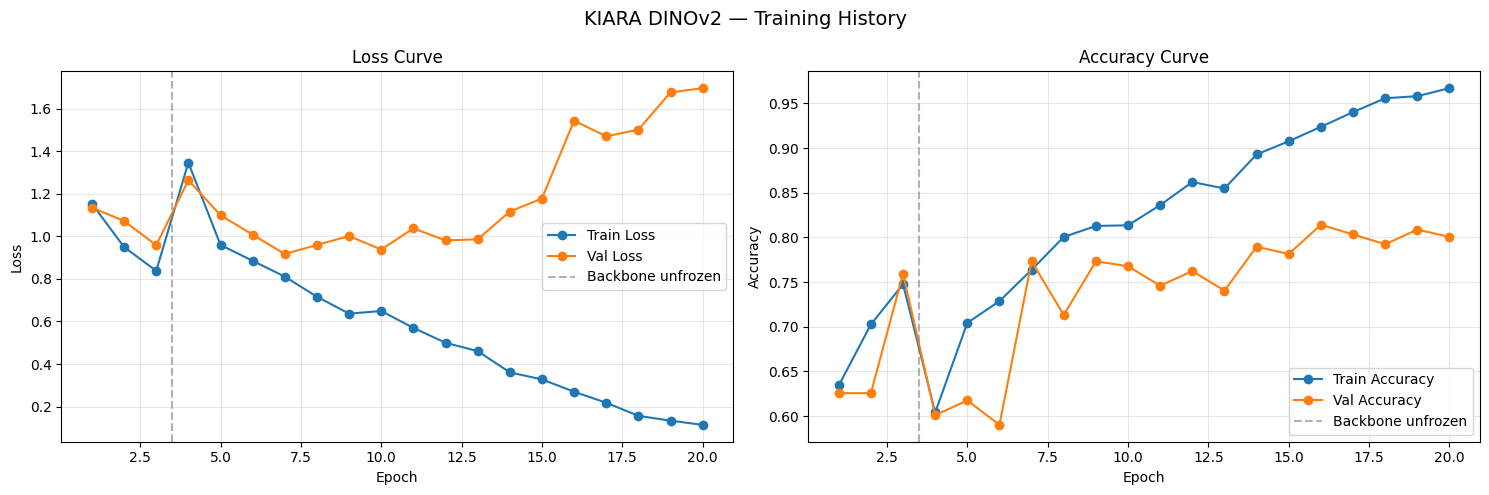

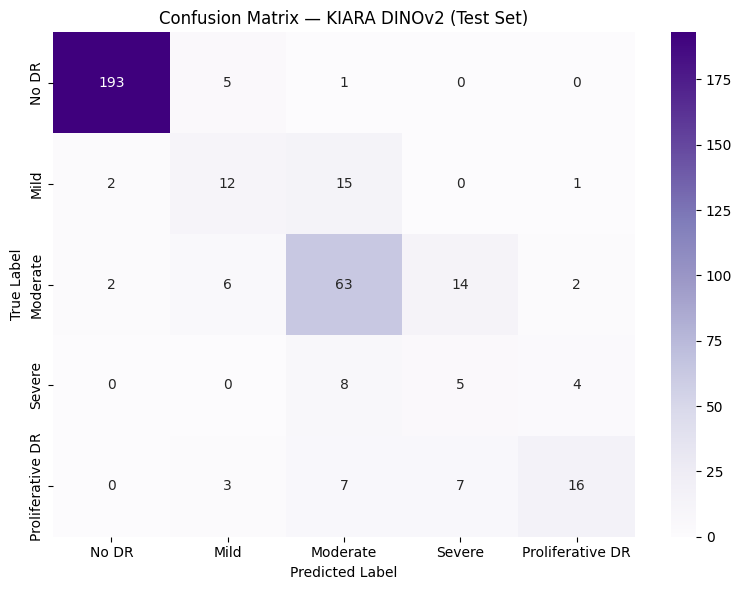

In [40]:
## Section 17 — Visualizations

# ------------------------------------------------------------------
# Training / validation accuracy and loss curves
# ------------------------------------------------------------------
epochs_range = range(1, len(history["train_loss"]) + 1)
unfreeze_epoch = CFG.FREEZE_BACKBONE_EPOCHS + 0.5

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(epochs_range, history["train_loss"], label="Train Loss", marker="o")
axes[0].plot(epochs_range, history["val_loss"], label="Val Loss", marker="o")
axes[0].axvline(unfreeze_epoch, color="gray", linestyle="--", alpha=0.6, label="Backbone unfrozen")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss Curve")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history["train_acc"], label="Train Accuracy", marker="o")
axes[1].plot(epochs_range, history["val_acc"], label="Val Accuracy", marker="o")
axes[1].axvline(unfreeze_epoch, color="gray", linestyle="--", alpha=0.6, label="Backbone unfrozen")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy Curve")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("KIARA DINOv2 — Training History", fontsize=14)
plt.tight_layout()
plt.show()
# ------------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------------
plt.figure(figsize=(8, 6))
sns.heatmap(
    test_cm, annot=True, fmt="d", cmap="Purples",
    xticklabels=[CFG.CLASS_NAMES[i] for i in range(CFG.NUM_CLASSES)],
    yticklabels=[CFG.CLASS_NAMES[i] for i in range(CFG.NUM_CLASSES)],
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix — KIARA DINOv2 (Test Set)")
plt.tight_layout()
plt.show()

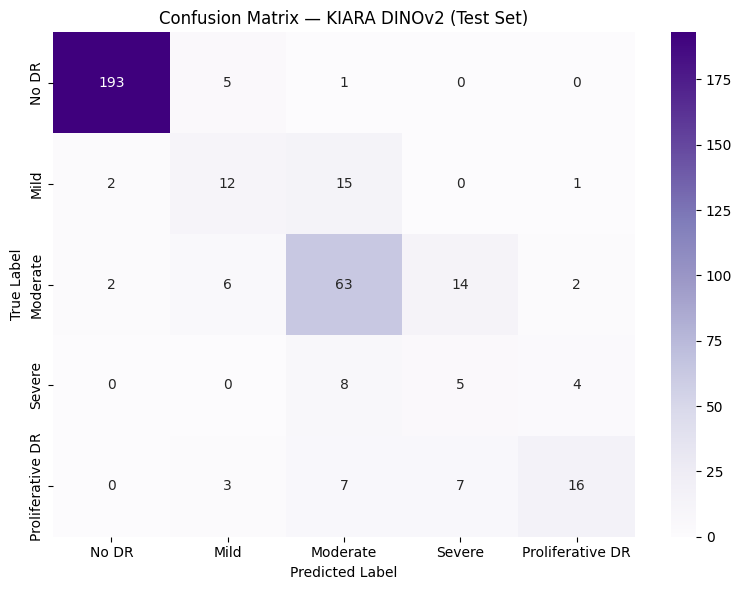

In [41]:
# ------------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------------
plt.figure(figsize=(8, 6))
sns.heatmap(
    test_cm, annot=True, fmt="d", cmap="Purples",
    xticklabels=[CFG.CLASS_NAMES[i] for i in range(CFG.NUM_CLASSES)],
    yticklabels=[CFG.CLASS_NAMES[i] for i in range(CFG.NUM_CLASSES)],
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix — KIARA DINOv2 (Test Set)")
plt.tight_layout()
plt.show()

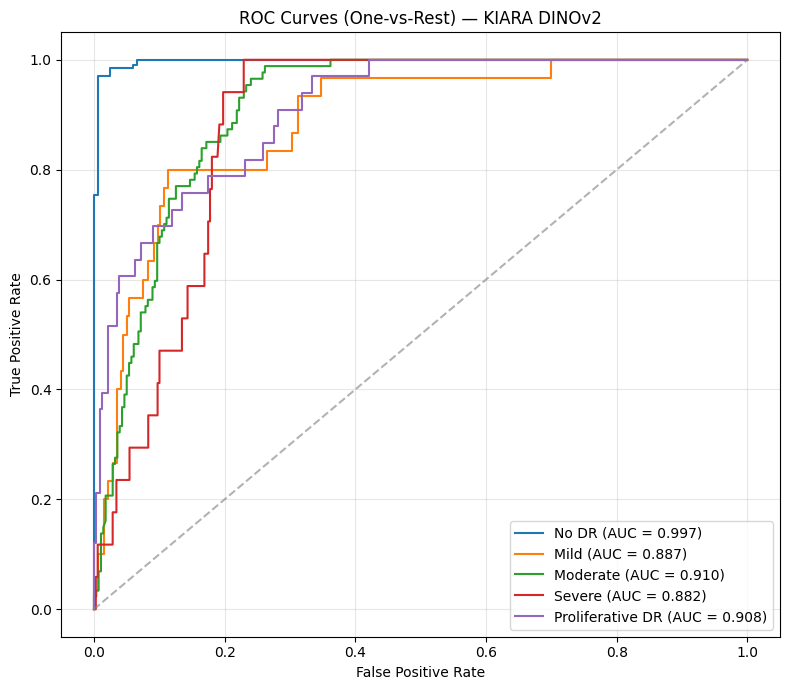

In [42]:
# ------------------------------------------------------------------
# ROC curves (One-vs-Rest)
# ------------------------------------------------------------------
test_true_bin = label_binarize(test_true, classes=list(range(CFG.NUM_CLASSES)))

plt.figure(figsize=(8, 7))
for cls_idx in range(CFG.NUM_CLASSES):
    fpr, tpr, _ = roc_curve(test_true_bin[:, cls_idx], test_probs[:, cls_idx])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{CFG.CLASS_NAMES[cls_idx]} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", alpha=0.6)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (One-vs-Rest) — KIARA DINOv2")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


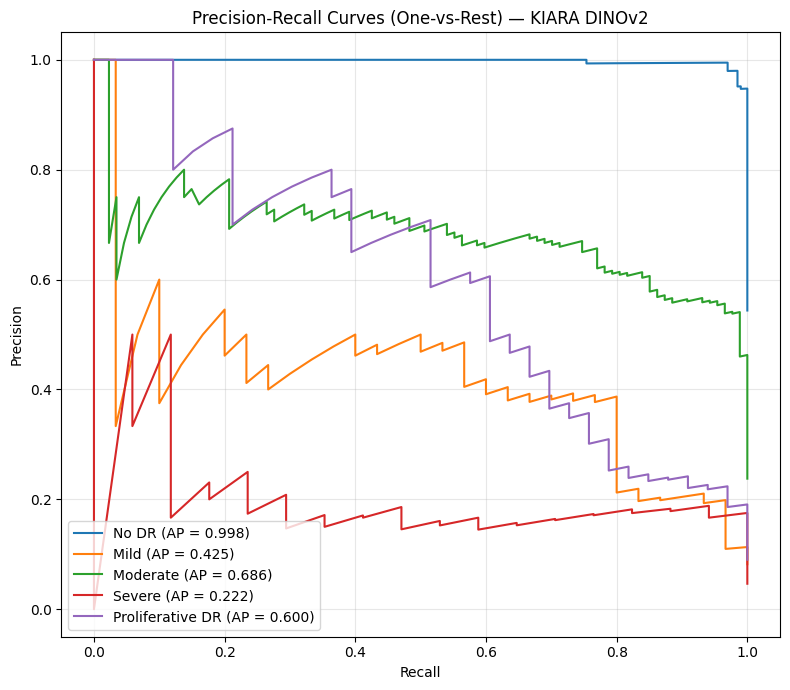

In [43]:
# ------------------------------------------------------------------
# Precision-Recall curves (One-vs-Rest)
# ------------------------------------------------------------------
plt.figure(figsize=(8, 7))
for cls_idx in range(CFG.NUM_CLASSES):
    precision_vals, recall_vals, _ = precision_recall_curve(
        test_true_bin[:, cls_idx], test_probs[:, cls_idx]
    )
    avg_precision = average_precision_score(test_true_bin[:, cls_idx], test_probs[:, cls_idx])
    plt.plot(recall_vals, precision_vals, label=f"{CFG.CLASS_NAMES[cls_idx]} (AP = {avg_precision:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves (One-vs-Rest) — KIARA DINOv2")
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [44]:
## Section 18 — Save Final Checkpoint

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "model_name": CFG.MODEL_NAME,
        "num_classes": CFG.NUM_CLASSES,
        "class_names": CFG.CLASS_NAMES,
        "img_size": CFG.IMG_SIZE,
        "imagenet_mean": CFG.IMAGENET_MEAN,
        "imagenet_std": CFG.IMAGENET_STD,
        "best_val_accuracy": float(max(history["val_acc"])),
        "qwk": float(test_qwk),
    },
    CFG.CHECKPOINT_PATH,
)

print("Best model saved successfully")
print("Checkpoint saved successfully")
print(f"\nFiles written:")
print(f"  {CFG.BEST_MODEL_PATH}")
print(f"  {CFG.CHECKPOINT_PATH}")


Best model saved successfully
Checkpoint saved successfully

Files written:
  best_dino_model.pth
  kiara_dino_checkpoint.pth


In [45]:
## Conclusion

print("CONCLUSION")
print("=" * 60)
print(f"""
KIARA DINOv2 (ViT-Base/14, self-supervised pretraining) achieved:
  Test Accuracy : {test_accuracy:.4f}
  Test QWK      : {test_qwk:.4f}
  Test F1       : {test_f1:.4f}

This run used the identical 224x224 resolution and identical
train/validation/test splits as the ResNet50, Vision Transformer, and
Swin Transformer notebooks in the KIARA comparison suite, with no
test-time augmentation applied, so these numbers are directly
comparable to those models' reported metrics in the
'KIARA - Model Comparison' notebook.

Because DINOv2 was pretrained via self-supervised distillation rather
than supervised ImageNet classification, a meaningfully different QWK
here relative to the supervised backbones (ResNet50, ViT, Swin) would
suggest self-supervised visual features transfer distinctly to retinal
fundus imagery -- worth highlighting explicitly in the cross-model
comparison writeup, alongside the resolution caveat noted in the
introduction (this notebook forced DINOv2 down to 224x224, well below
its native 518x518 pretraining resolution, specifically to keep the
comparison fair).
""")


CONCLUSION

KIARA DINOv2 (ViT-Base/14, self-supervised pretraining) achieved:
  Test Accuracy : 0.7896
  Test QWK      : 0.8841
  Test F1       : 0.7929

This run used the identical 224x224 resolution and identical
train/validation/test splits as the ResNet50, Vision Transformer, and
Swin Transformer notebooks in the KIARA comparison suite, with no
test-time augmentation applied, so these numbers are directly
comparable to those models' reported metrics in the
'KIARA - Model Comparison' notebook.

Because DINOv2 was pretrained via self-supervised distillation rather
than supervised ImageNet classification, a meaningfully different QWK
here relative to the supervised backbones (ResNet50, ViT, Swin) would
suggest self-supervised visual features transfer distinctly to retinal
fundus imagery -- worth highlighting explicitly in the cross-model
comparison writeup, alongside the resolution caveat noted in the
introduction (this notebook forced DINOv2 down to 224x224, well below
its native 518